<a href="https://colab.research.google.com/github/IrinXD/Trabalho-Final-Intelig-ncia-Artificial/blob/main/CodigoIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Importação de Bibliotecas e Leitura**:

In [1]:
# 1. Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Carregando o Dataset
# Certifique-se de que o arquivo .csv está na mesma pasta/ambiente do Colab
df = pd.read_csv('/content/sample_data/gym_members_exercise_tracking.csv')

# Exibindo as primeiras linhas para conferência
display(df.head())

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


## **Análise de Correlação**:

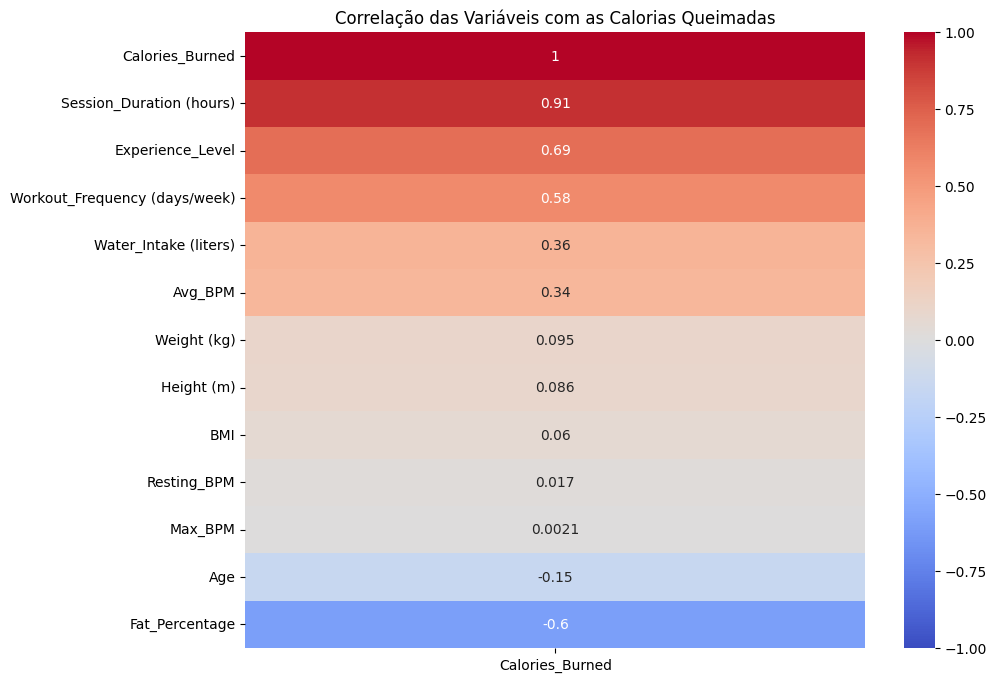

In [2]:
# Analisando a correlação das variáveis numéricas com a Variável Alvo (Calories_Burned)
plt.figure(figsize=(10, 8))
# Seleciona apenas colunas numéricas para a correlação
colunas_numericas = df.select_dtypes(include=[np.number])
correlacao = colunas_numericas.corr()

# Criando um mapa de calor (Heatmap)
sns.heatmap(correlacao[['Calories_Burned']].sort_values(by='Calories_Burned', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação das Variáveis com as Calorias Queimadas')
plt.show()

## **Tratamento e Criação dos Lotes**


In [3]:
# Transformando textos em números
df_tratado = pd.get_dummies(df, columns=['Gender', 'Workout_Type'], drop_first=True)
y = df_tratado['Calories_Burned']

# Separando os 4 lotes de testes (Adicionamos o Lote 2 com Experience_Level)
X_lote1 = df_tratado[['Session_Duration (hours)', 'Avg_BPM']]
X_lote2 = df_tratado[['Session_Duration (hours)', 'Experience_Level']]
X_lote3 = df_tratado[['Session_Duration (hours)', 'Experience_Level', 'Avg_BPM', 'Age', 'Weight (kg)', 'Fat_Percentage', 'Gender_Male']]
X_lote4 = df_tratado.drop('Calories_Burned', axis=1)

print("4 Lotes separados com sucesso!")

4 Lotes separados com sucesso!


## **Normalização e Divisão**

In [4]:
def preparar_dados(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test

X1_train, X1_test, y1_train, y1_test = preparar_dados(X_lote1, y)
X2_train, X2_test, y2_train, y2_test = preparar_dados(X_lote2, y)
X3_train, X3_test, y3_train, y3_test = preparar_dados(X_lote3, y)
X4_train, X4_test, y4_train, y4_test = preparar_dados(X_lote4, y)


print("Dados prontos para a IA!")

Dados prontos para a IA!


## **Treinando a Parte 1 (Modelo K-NN)**

In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Função para treinar e guardar o erro do K-NN
def executar_knn(X_train, X_test, y_train, y_test, nome_lote):
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    previsoes = knn.predict(X_test)
    erro = mean_absolute_error(y_test, previsoes)
    r2 = r2_score(y_test, previsoes)
    print(f"--- {nome_lote} (K-NN) ---")
    print(f"Acurácia (R²): {r2 * 100:.2f}% | Erro Médio: {erro:.2f} calorias\n")
    return erro

# Guardando os resultados nas variáveis globais (Agora com os 4 Lotes atualizados)
knn_mae_lote1 = executar_knn(X1_train, X1_test, y1_train, y1_test, "Lote 1 (A Hipótese Inicial)")
knn_mae_lote2 = executar_knn(X2_train, X2_test, y2_train, y2_test, "Lote 2 (A Correção pelos Dados)")
knn_mae_lote3 = executar_knn(X3_train, X3_test, y3_train, y3_test, "Lote 3 (Esforço + Corpo)")
knn_mae_lote4 = executar_knn(X4_train, X4_test, y4_train, y4_test, "Lote 4 (Todas as Variáveis)")

--- Lote 1 (A Hipótese Inicial) (K-NN) ---
Acurácia (R²): 93.00% | Erro Médio: 58.79 calorias

--- Lote 2 (A Correção pelos Dados) (K-NN) ---
Acurácia (R²): 77.71% | Erro Médio: 102.02 calorias

--- Lote 3 (Esforço + Corpo) (K-NN) ---
Acurácia (R²): 93.40% | Erro Médio: 61.17 calorias

--- Lote 4 (Todas as Variáveis) (K-NN) ---
Acurácia (R²): 77.16% | Erro Médio: 109.77 calorias



## **Treinando a Parte 2 (Modelo SVM)**

In [6]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

# Função para treinar e guardar o erro do SVM
def executar_svm(X_train, X_test, y_train, y_test, nome_lote):
    svm = SVR(kernel='linear')
    svm.fit(X_train, y_train)
    previsoes = svm.predict(X_test)
    erro = mean_absolute_error(y_test, previsoes)
    r2 = r2_score(y_test, previsoes)
    print(f"--- {nome_lote} (SVM) ---")
    print(f"Acurácia (R²): {r2 * 100:.2f}% | Erro Médio: {erro:.2f} calorias\n")
    return erro

# Guardando os resultados nas variáveis globais (Agora com os 4 Lotes atualizados)
svm_mae_lote1 = executar_svm(X1_train, X1_test, y1_train, y1_test, "Lote 1 (A Hipótese Inicial)")
svm_mae_lote2 = executar_svm(X2_train, X2_test, y2_train, y2_test, "Lote 2 (A Correção pelos Dados)")
svm_mae_lote3 = executar_svm(X3_train, X3_test, y3_train, y3_test, "Lote 3 (Esforço + Corpo)")
svm_mae_lote4 = executar_svm(X4_train, X4_test, y4_train, y4_test, "Lote 4 (Todas as Variáveis)")

--- Lote 1 (A Hipótese Inicial) (SVM) ---
Acurácia (R²): 91.98% | Erro Médio: 59.07 calorias

--- Lote 2 (A Correção pelos Dados) (SVM) ---
Acurácia (R²): 78.31% | Erro Médio: 104.63 calorias

--- Lote 3 (Esforço + Corpo) (SVM) ---
Acurácia (R²): 97.07% | Erro Médio: 37.33 calorias

--- Lote 4 (Todas as Variáveis) (SVM) ---
Acurácia (R²): 96.94% | Erro Médio: 38.19 calorias



## **Comparação e o Gráfico Final**

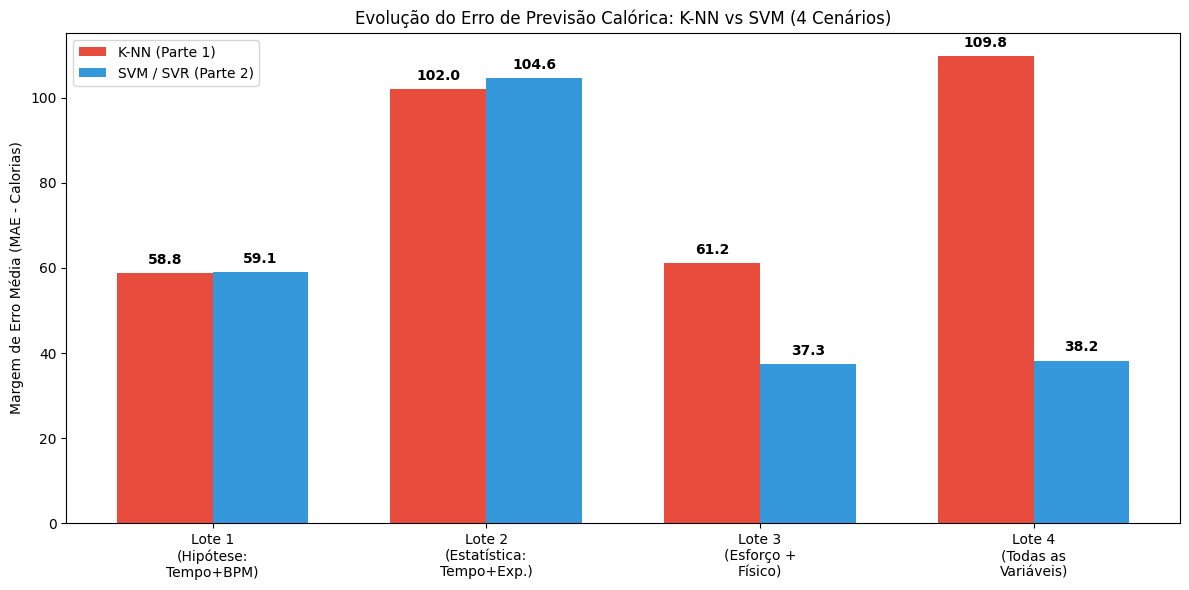

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Os valores REAIS exatos que você obteve no Colab
# Ordem: [Lote 1, Lote 2, Lote 3, Lote 4]
erros_knn = [58.79, 102.02, 61.17, 109.77]
erros_svm = [59.07, 104.63, 37.33, 38.19]

# 2. Configurando o eixo X (Lotes)
modelos = ['Lote 1\n(Hipótese:\nTempo+BPM)', 'Lote 2\n(Estatística:\nTempo+Exp.)', 'Lote 3\n(Esforço +\nFísico)', 'Lote 4\n(Todas as\nVariáveis)']
x = np.arange(len(modelos))
largura = 0.35

# 3. Desenhando o Gráfico de Barras Agrupadas
plt.figure(figsize=(12, 6))
barras_knn = plt.bar(x - largura/2, erros_knn, largura, label='K-NN (Parte 1)', color='#e74c3c')
barras_svm = plt.bar(x + largura/2, erros_svm, largura, label='SVM / SVR (Parte 2)', color='#3498db')

# Estilizando
plt.ylabel('Margem de Erro Média (MAE - Calorias)')
plt.title('Evolução do Erro de Previsão Calórica: K-NN vs SVM (4 Cenários)')
plt.xticks(x, modelos)
plt.legend()

# 4. Colocando os números exatos no topo de cada barra para a apresentação
for barra in barras_knn + barras_svm:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1.5, f'{yval:.1f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()